<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model

- Given the high prevalence of missing values and the likely non-linear relationships between features and the target, a boosting-based approach is well suited for this problem. I chose XGBoost due to its strong track record in handling imbalanced classification tasks and its flexibility in capturing complex, non-linear patterns.

- A common alternative in credit risk modeling is Logistic Regression; however, in its standard form it assumes linear decision boundaries. Given the observed feature behavior, this assumption is likely too restrictive for this dataset (though not formally tested here).

- The model is optimized using `log_loss`, while hyperparameter tuning is guided by `PR-AUC`, which is more appropriate for highly imbalanced datasets.

- This approach provides several advantages:
  - ability to model non-linear relationships  
  - native handling of missing values without requiring imputation  
  - robustness to multicollinearity among features  

- Model performance on the test set is moderate. In the context of risk scoring, correctly identifying positive cases (defaults) is typically more critical than minimizing false positives. Therefore, Recall is considered more important than Precision in this setting.



- Categorical features with NaNs
    - account_status,
    - account_worst_status_0_3m,
    - account_worst_status_12_24m,
    - account_worst_status_3_6m,
    - account_worst_status_6_12m,
    - num_arch_written_off_0_12m,
    - num_arch_written_off_12_24m,
    - worst_status_active_inv

- Categorical features no NaNs
    - merchant_category,
    - merchant_group,
    - has_paid,
    - name_in_email,
    - num_arch_dc_0_12m,
    - num_arch_dc_12_24m,
    - status_last_archived_0_24m, 
    - status_2nd_last_archived_0_24m,
    - status_3rd_last_archived_0_24m,
    - status_max_archived_0_6_months',
    - status_max_archived_0_12_months,
    - status_max_archived_0_24_months

- Numerical features with NaNs
    - account_days_in_dc_12_24m,
    - account_days_in_rem_12_24m,
    - account_days_in_term_12_24m,
    - account_incoming_debt_vs_paid_0_24m,
    - avg_payment_span_0_12m,
    - avg_payment_span_0_3m,
    - num_active_div_by_paid_inv_0_12m

- Numerical features no NaNs
    - account_amount_added_12_24m,
    - age,
    - max_paid_inv_0_12m,
    - max_paid_inv_0_24m,
    - num_active_inv,
    - num_arch_ok_0_12m,
    - num_arch_ok_12_24m,
    - num_arch_rem_0_12m,
    - num_unpaid_bills,
    - recovery_debt,
    - sum_capital_paid_account_0_12m,
    - sum_capital_paid_account_12_24m,
    - sum_paid_inv_0_12m,
    - time_hours

</div>

#### Load Data

In [14]:


import joblib
import shap 
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import warnings
import category_encoders as ce
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import roc_auc_score, recall_score, precision_score, average_precision_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import category_encoders as ce
from xgboost import XGBClassifier

import utils
import preprocessing
import importlib

importlib.reload(utils)
from utils import evaluate_and_report, evaluate_nn, plot_confusion_matrix

importlib.reload(preprocessing)
from preprocessing import QuantileBinner


from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

import category_encoders as ce


mlflow.set_experiment("credit-risk-models")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = '{:.5f}'.format



df = pd.read_csv("./dataset.csv", sep = ";")
df['has_paid'] = df['has_paid'].astype(int)

df_nna = df[df['default'].notna()]  # observations for which we have default values (Training + Validation set)
#df_na = df[df['default'].isna()]    # observations for which we dont have default values (Unlabeled data)

X = df_nna.drop(columns=["default"])
y = df_nna["default"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, stratify=y, test_size=0.2, random_state=42
# )


# 1. split off TEST (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# 2. split remaining into TRAIN (70%) and VAL (20%)
# 20 / 90 ≈ 0.2222
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2222,
    stratify=y_temp,
    random_state=42
)


# -------------------------
# FEATURE GROUPS
# -------------------------

cat_na_cols = [
    'account_status', 
    'account_worst_status_0_3m', 
    'account_worst_status_12_24m',
    'account_worst_status_3_6m', 
    'account_worst_status_6_12m',
    'num_arch_written_off_0_12m', 
    'num_arch_written_off_12_24m',
    'worst_status_active_inv'
]

cat_no_na_cols = [
    'merchant_category', 
    'merchant_group', 
    'has_paid', 
    'name_in_email',
    'num_arch_dc_0_12m', 
    'num_arch_dc_12_24m',
    'status_last_archived_0_24m', 
    'status_2nd_last_archived_0_24m',
    'status_3rd_last_archived_0_24m',
    'status_max_archived_0_6_months', 
    'status_max_archived_0_12_months',
    'status_max_archived_0_24_months'
]

num_na_cols = [
    'account_days_in_dc_12_24m', 
    'account_days_in_rem_12_24m',
    'account_days_in_term_12_24m', 
    'account_incoming_debt_vs_paid_0_24m',
    'avg_payment_span_0_12m', 
    'avg_payment_span_0_3m',
    'num_active_div_by_paid_inv_0_12m'
]

num_no_na_cols = [
    'account_amount_added_12_24m', 
    'age', 
    'max_paid_inv_0_12m',
    'max_paid_inv_0_24m', 
    'num_active_inv', 
    'num_arch_ok_0_12m',
    'num_arch_ok_12_24m', 
    'num_arch_rem_0_12m', 
    'num_unpaid_bills',
    'recovery_debt', 
    'sum_capital_paid_account_0_12m',
    'sum_capital_paid_account_12_24m', 
    'sum_paid_inv_0_12m',
    'time_hours'
]

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 1: Logistic regression V1
- Numerical features
    - account_days_in_dc_12_24m -             only 11% NAs, 0 is the median - impute median
    - account_days_in_rem_12_24m -            only 11% NAs, 0 is the median - impute median
    - account_days_in_term_12_24m -           only 11% NAs, 0 is the median - impute median
    - account_incoming_debt_vs_paid_0_24m -   assign it median or -999
    - avg_payment_span_0_3m -                 assign it median or -999
    - avg_payment_span_0_12m -                assign it median or -999
    - num_active_div_by_paid_inv_0_12m -      assign it median or -999

- For each numerical feature with NaNs, a "_missing" column is made indicating where the value was imputed
- All numerical features are standardized
    
- Categorical features
    - account_satus -               Categorical, make NA a new category -> target encoding
    - account_worst_status_0_3m -   Categorical, make NA a new category -> target encoding
    - account_worst_status_12_24m - Categorical, make NA a new category -> target encoding
    - account_worst_status_3_6m -   Categorical, make NA a new category -> target encoding
    - account_worst_status_6_12m -  Categorical, make NA a new category -> target encoding
    - num_arch_written_off_0_12m -  Categorical, make NA a new category -> target encoding
    - num_arch_written_off_12_24m - Categorical, make NA a new category -> target encoding
    - worst_status_active_inv -     Categorical, make NA a new category -> target encoding



</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV average_precision: 0.16079003603091785

Best Parameters:
clf__C: 0.1668100537200059

Test ROC AUC: 0.8930428367127867
Test PR AUC: 0.1489193330696014
Precision: 0.05739760378935636
Recall: 0.7984496124031008

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   14353    3383
Actual 1      52     206


2026/04/04 13:40:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 13:40:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


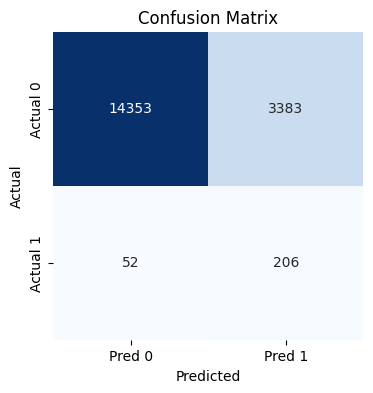

In [ ]:



all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_lr1 = X_train[feature_cols].copy()
X_val_lr1 = X_val[feature_cols].copy()
#X_test_lr1 = X_test[feature_cols].copy()

# -------------------------
# CREATE MISSING INDICATORS (IMPORTANT STEP)
# -------------------------

def add_missing_indicators(df, num_na_cols):
    df = df.copy()
    for col in num_na_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)
    return df

X_train_lr1 = add_missing_indicators(X_train_lr1, num_na_cols)
X_val_lr1 = add_missing_indicators(X_val_lr1, num_na_cols)

# indicator columns
num_indicator_columns = [f"{col}_missing" for col in num_na_cols]

# -------------------------
# PIPELINES
# -------------------------

# numeric with NA → impute + scale
num_na_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# numeric without NA → scale
num_no_na_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# indicators → passthrough (NO scaling!)
indicator_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

# categorical → impute + WoE
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("woe", ce.WOEEncoder(handle_missing='value', handle_unknown='value'))
])

# -------------------------
# PREPROCESSOR
# -------------------------

preprocessor = ColumnTransformer([
    ("num_na", num_na_pipeline, num_na_cols),
    ("num_no_na", num_no_na_pipeline, num_no_na_cols),
    ("indicators", indicator_pipeline, num_indicator_columns),
    ("cat_woe", cat_pipeline, all_cat_cols),
])

# -------------------------
# MODEL
# -------------------------

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        #penalty="l2",
        #solver="lbfgs",
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])

# -------------------------
# HYPERPARAMETERS
# -------------------------

param_dist = {
    "clf__C": np.logspace(-3, 2, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_lr1 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)



with mlflow.start_run(run_name="logreg_v1"):
   
    random_search_lr1.fit(X_train_lr1, y_train)  # TRAIN
    results = evaluate_and_report(random_search_lr1, X_val_lr1, y_val, threshold=0.5, ) # EVALUATE

    # =========================
    # LOG BEST PARAMS
    # =========================

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_lr1.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_lr1.best_params_)
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("penalty", "l1")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", 0.5)
    
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix_normalized.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_lr1.best_estimator_,
            artifact_path="model",
            input_example=X_val_lr1.head(5)
    )

In [55]:
evaluate_and_report(random_search_lr1, X_val_lr1, y_val, threshold=0.8, metric="average_precision")

Best CV average_precision: 0.16079003603091785

Best Parameters:
clf__C: 0.1668100537200059

Test ROC AUC: 0.8930428367127867
Test PR AUC: 0.1489193330696014
Precision: 0.13034623217922606
Recall: 0.49612403100775193

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   16882     854
Actual 1     130     128


{'roc_auc': 0.8930428367127867,
 'pr_auc': 0.1489193330696014,
 'precision': 0.13034623217922606,
 'recall': 0.49612403100775193,
 'confusion_matrix': array([[16882,   854],
        [  130,   128]])}

In [ ]:
X_test_lr1 = X_test[feature_cols].copy()
X_test_lr1 = add_missing_indicators(X_test_lr1, num_na_cols)

best_model = random_search_lr1.best_estimator_

def predict_single(model, X, y, idx, threshold = 0.5):
    x = X.iloc[[idx]]
    y_true = y.iloc[idx]
    
    prob = model.predict_proba(x)[0, 1]
    pred = int(prob >= threshold)
    
    print(f"Prediction: {pred}")
    print(f"Probability: {prob:.4f}")
    print(f"Actual: {y_true}")
    
    return prob, pred, y_true

predict_single(best_model, X_test_lr1, y_test, idx=15)

Prediction: 0
Probability: 0.0626
Actual: 0.0


(0.06262837740342972, 0, 0.0)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 2: Log Regression
- Numerical features -> median impute for NaNs + binning + WoE Encoding
- Categorical features -> WoE Encoding

- Potential improvements
    - monotonic binning
    - Add ratios
    - Log transforms
    - Caps - winsorization
    - try L1
    - interaction features
    - change class weight -> class_weight={0:1, 1:2}

X["debt_to_paid"] = X["recovery_debt"] / (X["sum_paid_inv_0_12m"] + 1)
X["active_to_paid"] = X["num_active_inv"] / (X["sum_paid_inv_0_12m"] + 1)

X["log_recovery_debt"] = np.log1p(X["recovery_debt"])

X["recovery_debt"] = X["recovery_debt"].clip(upper=X["recovery_debt"].quantile(0.99))

X["debt_x_active"] = X["recovery_debt"] * X["num_active_inv"]

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV average_precision: 0.15260832438821548

Best Parameters:
clf__C: 100.0


2026/04/04 20:44:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Test ROC AUC: 0.896365251946726
Test PR AUC: 0.13056055909088704
Precision: 0.057687074829931975
Recall: 0.8217054263565892

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   14273    3463
Actual 1      46     212


2026/04/04 20:44:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


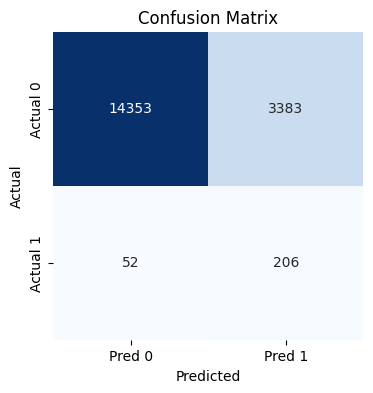

In [ ]:

all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols


# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_lr2 = X_train[feature_cols].copy()
X_val_lr2 = X_val[feature_cols].copy()


# -------------------------
# CREATE MISSING INDICATORS
# -------------------------

def add_missing_indicators(df, num_na_cols):
    df = df.copy()
    for col in num_na_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)
    return df

X_train_lr2 = add_missing_indicators(X_train_lr2, num_na_cols)
X_val_lr2 = add_missing_indicators(X_val_lr2, num_na_cols)

num_indicator_columns = [f"{col}_missing" for col in num_na_cols]


# -------------------------
# PIPELINES
# -------------------------

# numeric with NA -> impute -> bin -> WoE
num_na_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("binning", QuantileBinner(n_bins=5)),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])

# numeric without NA -> bin -> WoE
num_no_na_pipeline = Pipeline([
    ("binning", QuantileBinner(n_bins=5)),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])

# indicators -> passthrough
indicator_pipeline = "passthrough"

# categorical -> impute -> WoE
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])


# -------------------------
# PREPROCESSOR
# -------------------------

preprocessor = ColumnTransformer([
    ("num_na", num_na_pipeline, num_na_cols),
    ("num_no_na", num_no_na_pipeline, num_no_na_cols),
    ("indicators", indicator_pipeline, num_indicator_columns),
    ("cat_woe", cat_pipeline, all_cat_cols),
])


# -------------------------
# MODEL
# -------------------------

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])


# -------------------------
# HYPERPARAMETERS
# -------------------------

param_dist = {
    "clf__C": np.logspace(-3, 2, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_lr2 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

# -------------------------
# TRAIN
# -------------------------
with mlflow.start_run(run_name="logreg_v2"):

    random_search_lr2.fit(X_train_lr2, y_train.to_numpy()) #FIT
    results = evaluate_and_report(random_search_lr2, X_val_lr2, y_val.to_numpy(), threshold=0.5) #EVALUATE


    mlflow.set_tag("encoding", "woe + quantile_binning")   

    mlflow.set_tag("model_summary", 
    "Logistic regression with WoE encoding and quantile binning (credit risk)")

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_lr2.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_lr1.best_params_)
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("penalty", "l1")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", 0.5)
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix_normalized.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_lr2.best_estimator_,
            artifact_path="model",
            input_example=X_val_lr2.head(5)
    )
    

In [54]:
evaluate_and_report(random_search_lr2, X_val_lr2, y_val.to_numpy(), threshold=0.81)

Best CV average_precision: 0.15260832438821548

Best Parameters:
clf__C: 100.0

Test ROC AUC: 0.896365251946726
Test PR AUC: 0.13056055909088704
Precision: 0.13631522896698617
Recall: 0.49612403100775193

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   16925     811
Actual 1     130     128


{'roc_auc': 0.896365251946726,
 'pr_auc': 0.13056055909088704,
 'precision': 0.13631522896698617,
 'recall': 0.49612403100775193,
 'confusion_matrix': array([[16925,   811],
        [  130,   128]])}

In [ ]:
X_test_lr2 = X_test[feature_cols].copy()
X_test_lr2 = add_missing_indicators(X_test_lr2, num_na_cols)

best_model = random_search_lr2.best_estimator_

predict_single(best_model, X_test_lr2, y_test, idx=300)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 3: XGBoost
- No feature manipulation

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   2.1s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   2.1s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   2.2s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   2.3s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   2.4s
[CV] END colsample_bytree=0.8, gam

2026/04/04 20:34:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 20:34:04 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: MlflowException("Failed to enforce schema of data '      account_status account_worst_status_0_3m account_worst_status_12_24m  \\\n63913            NaN                       NaN                         NaN   \n69811            NaN                       NaN                         NaN   \n52471        1.00000                   1.00000                         NaN   \n24117        1.00000                   1.00000                     1.00000   \n37672            NaN                       NaN                         NaN   \n\n      account_worst_status_3_6m account_worst_status_6_12m  \\\n63913                       NaN                        NaN   \n69811                       NaN                        NaN   \n52471                   1.00000                    1.0

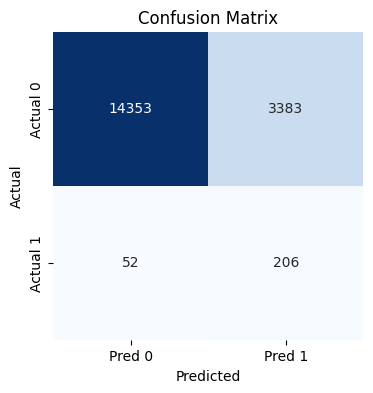

In [ ]:


all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_xgb1 = X_train[feature_cols].copy()
X_val_xgb1 = X_val[feature_cols].copy()
# =========================
# CAST CATEGORICAL COLUMNS
# =========================

for col in all_cat_cols:
    X_train_xgb1[col] = X_train_xgb1[col].astype("category")
    X_val_xgb1[col] = X_val_xgb1[col].astype("category")
    X_val_xgb1[col] = X_val_xgb1[col].cat.set_categories(
        X_train_xgb1[col].cat.categories
    )

# =========================
# CLASS IMBALANCE
# =========================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# =========================
# MODEL
# =========================

model = XGBClassifier(
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    enable_categorical=True,
    tree_method="hist",
)

# =========================
# HYPERPARAMETERS
# =========================

param_dist = {
    "n_estimators": [200, 300, 500, 1000],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": np.linspace(0, 2, 5),
    "min_child_weight": [1, 3, 5, 10],
    "reg_lambda": np.linspace(0, 3, 5),
    "reg_alpha": np.linspace(0, 3, 5),
}

# =========================
# CROSS-VALIDATION
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb1 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score="raise",
)


with mlflow.start_run(run_name="xgb_v1"):

    random_search_xgb1.fit(X_train_xgb1, y_train)

    results =  evaluate_and_report(
        random_search_xgb1,
        X_val_xgb1,
        y_val,
        threshold=0.5,
        metric="average_precision",
    )


    mlflow.set_tag("encoding", "no encoding done")   
    mlflow.set_tag("model_summary", "XgBoost")

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_xgb1.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_xgb1.best_params_)
    mlflow.log_param("model_type", "XgBoost")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", 0.5)
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_xgb1.best_estimator_,
            name="model",
            input_example=X_val_xgb1.head(5)
    )
    

In [50]:
evaluate_and_report( random_search_xgb1, X_val_xgb1, y_val, threshold=0.3053, metric="average_precision")

Best CV average_precision: 0.18701164670847925

Best Parameters:
subsample: 0.9
reg_lambda: 3.0
reg_alpha: 2.25
n_estimators: 1000
min_child_weight: 10
max_depth: 8
learning_rate: 0.02
gamma: 1.5
colsample_bytree: 0.9

Test ROC AUC: 0.8878639512155891
Test PR AUC: 0.2364486964521568
Precision: 0.13326446280991736
Recall: 0.5

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   16897     839
Actual 1     129     129


{'roc_auc': 0.8878639512155891,
 'pr_auc': 0.2364486964521568,
 'precision': 0.13326446280991736,
 'recall': 0.5,
 'confusion_matrix': array([[16897,   839],
        [  129,   129]])}

In [ ]:
X_test_xgb1 = X_test[feature_cols].copy()

for col in all_cat_cols:
    X_test_xgb1[col] = X_test_xgb1[col].astype("category")
    X_test_xgb1[col] = X_test_xgb1[col].cat.set_categories(
        X_train_xgb1[col].cat.categories
    )

best_model = random_search_xgb1.best_estimator_

predict_single(best_model, X_test_xgb1, y_test, idx=10)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 4: XGBoost
- WoE Encoding for categorical and numerical values with NaNs 

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  13.5s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  13.6s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  13.8s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  13.9s
[CV] END clf__colsample_bytree=0.8,

2026/04/05 11:51:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


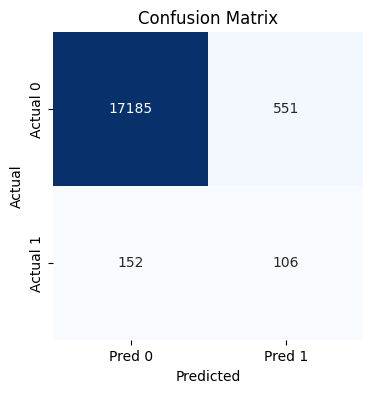

In [9]:


all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_xgb2 = X_train[feature_cols].copy()
X_val_xgb2 = X_val[feature_cols].copy()



# PIPELINES

# numeric with NA → bin + WoE
num_na_pipeline = Pipeline([
    ("binning", QuantileBinner(n_bins=10)),
    ("woe", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

# numeric without NA → passthrough
num_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

# categorical → WoE (NA handled internally)
cat_pipeline = Pipeline([
    ("encoder", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

preprocessor = ColumnTransformer([
    ("num_na_woe", num_na_pipeline, num_na_cols),
    ("num", num_pipeline, num_no_na_cols),
    ("cat_woe", cat_pipeline, all_cat_cols),
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", XGBClassifier(
        #eval_metric="auc",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False
    ))
])

param_dist = {
    "clf__n_estimators": [200,300,500,1000],
    "clf__max_depth": [3, 5, 8],
    "clf__learning_rate": [0.01, 0.02, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__gamma": np.linspace(0, 2, 5),
    "clf__min_child_weight": [1, 3, 5, 10],
    "clf__reg_lambda": np.linspace(0, 3, 5),
    "clf__reg_alpha": np.linspace(0, 3, 5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb2 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    #scoring="roc_auc",
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

with mlflow.start_run(run_name="xgb_v2"):

    # MODEL TRAINING
    random_search_xgb2.fit(X_train_xgb2, y_train)

    results = evaluate_and_report(
        random_search_xgb2, 
        X_val_xgb2, y_val, 
        threshold=0.5, 
        metric="average_precision"
    )


    mlflow.set_tag("encoding", "for categorical and numerical features with NaNs: Binning + WoE")   
    mlflow.set_tag("model_summary", "XgBoost")

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_xgb2.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_xgb2.best_params_)
    mlflow.log_param("model_type", "XgBoost")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", 0.5)
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_xgb2.best_estimator_,
            name="model",
            input_example=X_val_xgb2.head(5)
    )

In [59]:
evaluate_and_report(random_search_xgb2, X_val_xgb2, y_val, threshold=0.385, metric="average_precision")

Best CV average_precision: 0.19302374816983048

Best Parameters:
clf__subsample: 0.9
clf__reg_lambda: 3.0
clf__reg_alpha: 2.25
clf__n_estimators: 1000
clf__min_child_weight: 10
clf__max_depth: 8
clf__learning_rate: 0.02
clf__gamma: 1.5
clf__colsample_bytree: 0.9

Test ROC AUC: 0.8916906401555282
Test PR AUC: 0.25038930419146377
Precision: 0.12942366026289182
Recall: 0.49612403100775193

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   16875     861
Actual 1     130     128


{'roc_auc': 0.8916906401555282,
 'pr_auc': 0.25038930419146377,
 'precision': 0.12942366026289182,
 'recall': 0.49612403100775193,
 'confusion_matrix': array([[16875,   861],
        [  130,   128]])}

In [ ]:
X_test_xgb2 = X_test[feature_cols].copy()

best_model = random_search_xgb2.best_estimator_

predict_single(best_model, X_test_xgb2, y_test, idx=10)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 5: Dense Neural Network
- Median inpute for NaNs of numerical features
- Numerical features are standardized
- Categorical features are encoded

</div>

Epoch 1 | Train: 1.0977 | Val: 1.0562 | AUC: 0.8425 | PR: 0.1063
Epoch 2 | Train: 0.9938 | Val: 0.9919 | AUC: 0.8575 | PR: 0.1207
Epoch 3 | Train: 0.9455 | Val: 0.9644 | AUC: 0.8635 | PR: 0.1301
Epoch 4 | Train: 0.9049 | Val: 0.9475 | AUC: 0.8684 | PR: 0.1385
Epoch 5 | Train: 0.8676 | Val: 0.9300 | AUC: 0.8722 | PR: 0.1481
Epoch 6 | Train: 0.8386 | Val: 0.9090 | AUC: 0.8732 | PR: 0.1590
Epoch 7 | Train: 0.8128 | Val: 0.8880 | AUC: 0.8757 | PR: 0.1624
Epoch 8 | Train: 0.7938 | Val: 0.8833 | AUC: 0.8764 | PR: 0.1647
Epoch 9 | Train: 0.7604 | Val: 0.8787 | AUC: 0.8756 | PR: 0.1691
Epoch 10 | Train: 0.7362 | Val: 0.8784 | AUC: 0.8756 | PR: 0.1699
Epoch 11 | Train: 0.7336 | Val: 0.8797 | AUC: 0.8766 | PR: 0.1545
Epoch 12 | Train: 0.7122 | Val: 0.8853 | AUC: 0.8751 | PR: 0.1651
Epoch 13 | Train: 0.7057 | Val: 0.8930 | AUC: 0.8763 | PR: 0.1680
Epoch 14 | Train: 0.6986 | Val: 0.9004 | AUC: 0.8747 | PR: 0.1676
Epoch 15 | Train: 0.6737 | Val: 0.9052 | AUC: 0.8732 | PR: 0.1706
Epoch 16 | Train: 0

2026/04/05 12:38:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/05 12:38:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


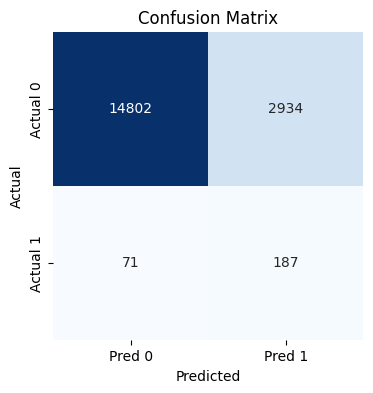

In [19]:

all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols

# =========================
# 0. SEED
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# 1. COPY DATA
# =========================

X_train_nn1 = X_train.copy()
X_val_nn1 = X_val.copy()

# =========================
# 2. DEFINE COLUMNS
# =========================

cat_columns = cat_na_cols + cat_no_na_cols
num_columns = num_na_cols + num_no_na_cols

# =========================
# 3. ENCODE CATEGORICALS
# =========================

cat_encoders = {}

for col in cat_columns:
    X_train_nn1[col] = X_train_nn1[col].astype(str).fillna("MISSING")
    X_val_nn1[col] = X_val_nn1[col].astype(str).fillna("MISSING")
    
    unique_vals = sorted(X_train_nn1[col].unique().tolist())
    
    if "MISSING" not in unique_vals:
        unique_vals.append("MISSING")
    
    encoder = {val: i for i, val in enumerate(unique_vals)}
    
    X_train_nn1[col] = X_train_nn1[col].map(encoder).astype(int)
    X_val_nn1[col] = X_val_nn1[col].map(
        lambda x: encoder.get(x, encoder["MISSING"])
    ).astype(int)
    
    cat_encoders[col] = encoder

# =========================
# 4. NUMERICAL PREPROCESSING
# =========================

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_nn1[num_columns] = imputer.fit_transform(X_train_nn1[num_columns])
X_val_nn1[num_columns] = imputer.transform(X_val_nn1[num_columns])

X_train_nn1[num_columns] = scaler.fit_transform(X_train_nn1[num_columns])
X_val_nn1[num_columns] = scaler.transform(X_val_nn1[num_columns])

# =========================
# 5. DATASET
# =========================

class TabularDataset(Dataset):
    def __init__(self, X, y, cat_cols, num_cols):
        self.X_cat = torch.tensor(X[cat_cols].values, dtype=torch.long)
        self.X_num = torch.tensor(X[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

# =========================
# 6. DATALOADERS
# =========================

train_dataset = TabularDataset(X_train_nn1, y_train, cat_columns, num_columns)
val_dataset = TabularDataset(X_val_nn1, y_val, cat_columns, num_columns)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# =========================
# 7. MODEL
# =========================

class TabularNN(nn.Module):
    def __init__(self, cat_dims, num_dim):
        super().__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, min(16, int(cat_dim**0.5)))
            for cat_dim in cat_dims
        ])
        
        emb_dim = sum([emb.embedding_dim for emb in self.embeddings])
        
        self.model = nn.Sequential(
            nn.Linear(emb_dim + num_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x_cat, x_num):
        emb = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.embeddings)]
        x = torch.cat(emb + [x_num], dim=1)
        return self.model(x).squeeze(1)

# =========================
# 8. INIT MODEL
# =========================

cat_dims = [len(cat_encoders[col]) for col in cat_columns]
num_dim = len(num_columns)

model = TabularNN(cat_dims, num_dim)

# =========================
# 9. TRAINING SETUP
# =========================

optimizer = optim.Adam(model.parameters(), lr=0.0001)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# =========================
# 10. TRAINING LOOP + EARLY STOPPING
# =========================

import mlflow
import mlflow.pytorch
import copy
import torch
import numpy as np

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    confusion_matrix
)

EPOCHS = 50
patience = 5

best_pr = 0
counter = 0
best_state = None
best_epoch = 0

# safe reset (notebook friendly)
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="dnn_v1"):

    # ===== TAGS =====
    mlflow.set_tag("model_type", "dnn")
    mlflow.set_tag("encoding", "median_imputation + standardization")

    # ===== PARAMS =====
    mlflow.log_params({
        "epochs": EPOCHS,
        "batch_size": 256,
        "learning_rate": 1e-4,
        "patience": patience
    })

    for epoch in range(EPOCHS):

        # ===== TRAIN =====
        model.train()
        total_loss = 0

        for x_cat, x_num, y_batch in train_loader:
            optimizer.zero_grad()

            logits = model(x_cat, x_num)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for x_cat, x_num, y_batch in val_loader:
                logits = model(x_cat, x_num)

                val_loss += criterion(logits, y_batch).item()

                probs = torch.sigmoid(logits)
                all_preds.append(probs.cpu())
                all_targets.append(y_batch.cpu())

        all_preds = torch.cat(all_preds).numpy()
        all_targets = torch.cat(all_targets).numpy()

        val_loss /= len(val_loader)
        val_auc = roc_auc_score(all_targets, all_preds)
        val_pr = average_precision_score(all_targets, all_preds)

        # ===== LOG TRAINING METRICS =====
        mlflow.log_metrics({
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_auc": val_auc,
            "val_pr": val_pr
        }, step=epoch)

        print(
            f"Epoch {epoch+1} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f} | "
            f"AUC: {val_auc:.4f} | "
            f"PR: {val_pr:.4f}"
        )

        # ===== EARLY STOPPING =====
        improved = val_pr > best_pr
        best_pr = val_pr if improved else best_pr
        counter = 0 if improved else counter + 1

        if improved:
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if counter >= patience:
            print("Early stopping")
            break

    # ===== LOAD BEST MODEL =====
    model.load_state_dict(best_state)
    model.eval()

    # ===== FINAL EVALUATION =====
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x_cat, x_num, y_batch in val_loader:
            logits = model(x_cat, x_num)
            probs = torch.sigmoid(logits)

            all_preds.append(probs.cpu())
            all_targets.append(y_batch.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    # ===== FINAL METRICS =====
    roc_auc = roc_auc_score(all_targets, all_preds)
    pr_auc = average_precision_score(all_targets, all_preds)

    threshold = 0.5
    pred_labels = (all_preds > threshold).astype(int)

    precision = precision_score(all_targets, pred_labels)
    recall = recall_score(all_targets, pred_labels)

    cm = confusion_matrix(all_targets, pred_labels)

    # ===== LOG FINAL METRICS =====
    mlflow.log_metrics({
        "best_val_pr": best_pr,
        "best_epoch": best_epoch,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall
    })

    # ===== LOG CONFUSION MATRIX =====
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix.png")

    # ===== LOG MODEL =====
    mlflow.pytorch.log_model(model, name="model")

In [61]:
evaluate_nn(model, val_loader, threshold=0.73)


Evaluation Results
------------------
ROC AUC: 0.873876283685265
PR AUC: 0.17583848117906853
Precision: 0.10951979780960404
Recall: 0.5038759689922481

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   16679    1057
Actual 1     128     130


{'roc_auc': 0.873876283685265,
 'pr_auc': 0.17583848117906853,
 'precision': 0.10951979780960404,
 'recall': 0.5038759689922481}

In [63]:
X_test_nn1 = X_test.copy()

for col in cat_columns:
    X_test_nn1[col] = X_test_nn1[col].astype(str).fillna("MISSING")
    
    encoder = cat_encoders[col]
    
    X_test_nn1[col] = X_test_nn1[col].map(
        lambda x: encoder.get(x, encoder["MISSING"])
    ).astype(int)


X_test_nn1[num_columns] = imputer.transform(X_test_nn1[num_columns])
X_test_nn1[num_columns] = scaler.transform(X_test_nn1[num_columns])


def predict_single_nn(model, X, y, threshold, idx):
    model.eval()
    
    x_cat = torch.tensor(
        X.iloc[[idx]][cat_columns].values, dtype=torch.long
    )
    x_num = torch.tensor(
        X.iloc[[idx]][num_columns].values, dtype=torch.float32
    )
    
    y_true = y.iloc[idx]
    
    with torch.no_grad():
        logits = model(x_cat, x_num)
        prob = torch.sigmoid(logits).item()
    
    pred = int(prob >= threshold)
    
    print(f"Prediction: {pred}")
    print(f"Probability: {prob:.4f}")
    print(f"Actual: {y_true}")
    
    return prob, pred, y_true


predict_single_nn(model, X_test_nn1, y_test, threshold=0.5, idx=10)

Prediction: 0
Probability: 0.4995
Actual: 0.0


(0.49948030710220337, 0, 0.0)

# Model Shipping

#### Serialize the model

In [ ]:
best_model = random_search_xgb1.best_estimator_
joblib.dump({
    "model": best_model,
    "features": X_train.columns.tolist()
}, "model_bundle.pkl")

#### Load and run the model

In [ ]:

bundle = joblib.load('./model_bundle.pkl')

mod = bundle["model"]
features = bundle["features"]

temp = pd.read_json("loan5.json")
temp = temp.reindex(columns=features)
temp["pd"] = mod.predict_proba(temp)[:, 1]

print(temp[["uuid", "pd"]])

#### Feature Importance with Shap

In [ ]:
xgb_model = mod.named_steps["clf"]
X_transformed = mod.named_steps["preprocessing"].transform(temp)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=features,
    plot_type="bar"
)